Emre Alca
title: Generalized Aldous Shepp Demo.ipynb
date: 2025-01-18 11:52:19

In [52]:
from linearframework.linear_framework_graph import LinearFrameworkGraph
import linearframework.linear_framework_results as lfr

from tqdm import tqdm
import networkx as nx
import sympy as sp
from math import factorial
import numpy as np
import matplotlib.pyplot as plt

This notebook builds on the notes: `A conjecture for the refinement of the Aldous-Shepp theorem.pdf` found in this folder. This notebook also assumes familiarity with the material in `Graph Tutorial.ipynb` and `Steady-State and Transient Quantities tutorial.ipynb`.

Let's recall from that note, that we are trying to show that for any graph with $n > 1$ vertices $G_n$, it's generalized randomness parameter $s_m(G)$ is bounded below by the generalized randomness parameter on the Erlang Process:
$$
    s_m(G_n) \geq s_m(E_n).
$$
or more explicitly
$$
    \frac{\langle t(G)^m \rangle}{\langle t(G) \rangle^m} \geq \frac{\prod_{j=0}^{m-1} (n-1+j)}{(n-1)^m}
$$
let's remember that this is a measure of the statistics of a dwell time distribution--first passage times through a Markov process, which is only well defined when there is a path from the source state to the target state.

In this notebook, we will test this conjecture numerically.
We do this by
- generating random graphs using networkx and ensure it has a path from our selected source to our selected target
- translating the networkx graph into a LinearFrameworkGraph
- calculate the generalized randomness parameter for our random graph
- calculate our expected lower bound
- generate a number of random sets of transition rates between states and substitute them into the symbolic expression for the generalized randomness parameter
- use these samples to test our conjecture

Let's begin by generating a random graph using networkx and ensuring it has a path from our source to our target.

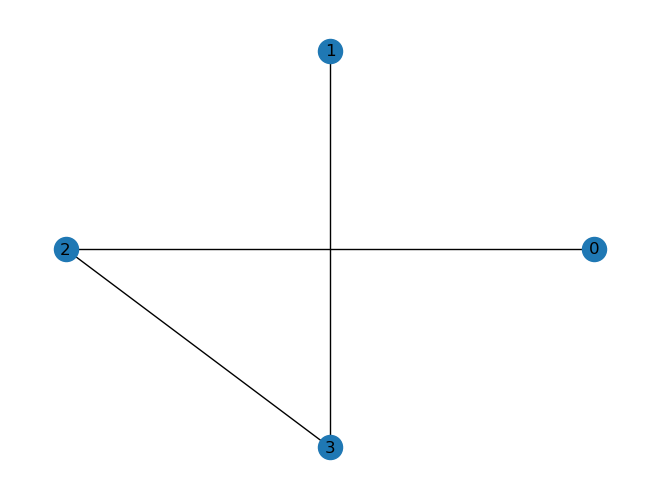

In [68]:
num_vertices = 4
edge_probability = 0.5

source = 0
target = num_vertices - 1

random_nx_graph = nx.erdos_renyi_graph(num_vertices, edge_probability, directed=False)

nx.draw_circular(random_nx_graph, with_labels=True)

assert nx.has_path(random_nx_graph, source, target) # ensuring there is a path from the source to the target

Now we can turn this networkx graph into a LinearFrameworkGraph

One current limitation of LinearFramework.py is that we can only calculate the higher moments of graphs which have no terminal vertices. This paradigm can still approximate graphs with terminal vertices by setting one direction of a transition to be much higher than it's reverse, but terminal functionality is upcoming.

So we take each edge in both directions.

The first-passage-time as an operation treats the target vertex as a terminal vertex in any case. This further aligns with our assumption that the each step of the kinesin motor is a first passage time through a reversible markov process--that the only irreversible transition is taking a step.

In [69]:
bidirectional_edges = list(random_nx_graph.edges)

for edge in bidirectional_edges.copy():
    bidirectional_edges.append((edge[1], edge[0]))

random_graph = LinearFrameworkGraph(bidirectional_edges)

random_graph.edges

[(0, 2), (1, 3), (2, 3), (2, 0), (3, 1), (3, 2)]

With this graph in mind, we can calculate our randomness parameter. Do note that this calculation can be fairly computationally expensive

In [70]:
moment = 3

generalized_randomness_param_numerator = lfr.k_moment_fpt_expression(random_graph, source, target, moment)
generalized_randomness_param_denominator = lfr.k_moment_fpt_expression(random_graph, source, target, 1) ** moment

generalized_randomness_param = generalized_randomness_param_numerator / generalized_randomness_param_denominator

generalized_randomness_param

(6*(-l_1**2 + l_1*(l_1 + l_2))**2*(l_4*(-l_3 - l_4) + l_4*(l_2 + l_3 + l_4)) + 12*(-l_1**2 + l_1*(l_1 + l_2))*(l_4*(-l_3 - l_4) + l_4*(l_2 + l_3 + l_4))*(-l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(l_3 + l_4)/2) + 6*(-l_1**2 + l_1*(l_1 + l_2))*(l_4*(-l_3 - l_4) + l_4*(l_2 + l_3 + l_4))*(l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(-l_3 - l_4) + (l_1 + l_2)*(l_3 + l_4)/2) + 6*(-l_1**2 + l_1*(l_1 + l_2))*(-l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(l_3 + l_4)/2)**2 + 6*(-l_1**2 + l_1*(l_1 + l_2))*(-l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(l_3 + l_4)/2)*(l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(-l_3 - l_4) + (l_1 + l_2)*(l_3 + l_4)/2) + 6*(-l_1**2 + l_1*(l_1 + l_2))*(l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(-l_3 - l_4) + (l_1 + l_2)*(l_3 + l_4)/2)**2 + 6*(-l_1*(l_2 + l_3 + l_4)/2 + l_2*(l_1 + l_3 + l_4)/2 + (l_1 + l_2)*(l_3 + l_4)/2)**3)/(-l_1**2 + l_1*(l

and let's also calculate our expected bound:

In [71]:
def generalized_randomness_param_erlang(n, m):
    """
    calculates the m-th generalized randomness parameter of an erlang process on n vertices

    Args:
        n (int): the number of vertices in the erlang process.
        m (int): the moment in the numerator, and the exponent in the denominator of the generalized randomness parameter.

    Returns:
        float: the m-th generalized randomness parameter of an erlang process on n vertices
    """
    
    numerator = factorial(n + m - 2)

    denominator = factorial(n - 2)
    denominator *= (n-1)**m
    return numerator / denominator

expected_lower_bound = generalized_randomness_param_erlang(num_vertices, moment)

expected_lower_bound

2.2222222222222223

There are tools built into linearframework.py that make it easier to perform monte-carlo simulations.

There is a method for `LinearFrameworkGraph` objects which allows you to input a specific `edge_to_weight` dictionary, and get a `sym_to_weight` dictionary you can use to evaluate your symbolic expression at a point.

Let's try with a uniformly sampled `edge_to_weight` dictionary

In [72]:
edge_to_weight = random_graph.generate_random_edge_to_weight()

sym_to_weight = random_graph.make_sym_to_weight(edge_to_weight)

sym_to_weight

{l_1: 32.5655989222598,
 l_2: 5.666931667065631,
 l_3: 0.07779398281214944,
 l_4: 36.59251767061046,
 l_5: 356.75058894574425,
 l_6: 0.0053743197170371656}

Or, if we run `graph.make_sym_to_weight()` with no arguments, the function calls `graph.generate_random_edge_to_weight()` automatically

In [73]:
sym_to_weight = random_graph.make_sym_to_weight()

sym_to_weight

{l_1: 0.12913464676685069,
 l_2: 187.83256119917095,
 l_3: 0.45179899246683286,
 l_4: 9.195083089911256,
 l_5: 0.2812678519945896,
 l_6: 411.89968433454914}

In [74]:
generalized_randomness_param.subs(sym_to_weight)

5.99267436272703

And we can repeat this a number of times.

In [75]:
num_samples = 1000

data_points = []

for sample in tqdm(range(num_samples)):
    new_sym_to_weight = random_graph.make_sym_to_weight()

    new_point = generalized_randomness_param.subs(new_sym_to_weight)

    data_points.append(new_point)

# data_points

100%|██████████| 1000/1000 [00:14<00:00, 68.66it/s]


And then we can plot these points, in comparison with our expected lower bound

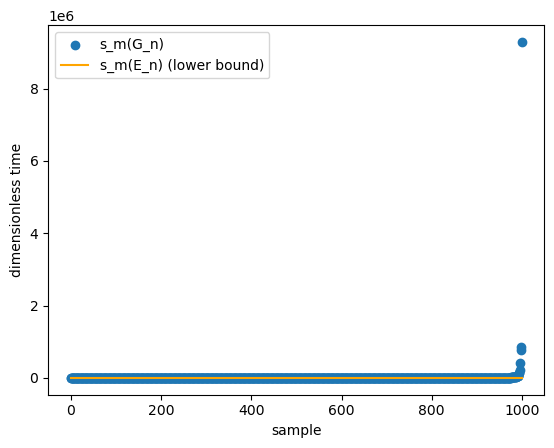

In [66]:
plt.scatter(np.arange(num_samples), np.sort(data_points), label='s_m(G_n)')
plt.plot(np.ones(num_samples)*expected_lower_bound, label='s_m(E_n) (lower bound)', color='orange')
plt.legend()
plt.ylabel('dimensionless time')
plt.xlabel('sample')
plt.show()

we can also check numerically whether our bound is violated.

If the following statement is True, the bound is violated

In [45]:
min(data_points) < expected_lower_bound

False

This is a toy numerical experiment. When we perform proper experiment, we take millions of samples. I would encourage you (the reader) to play with the moment of interest, the number of samples, or with specific graph structures.

The calculation of the moment expression can be quite expensive, but the method does run in polynomial time. I am running into some issues with stack size limitations within sympy, which may cause some other issues.